# Clase 10:  Value at Risk con Monte Carlo y Volatilidad Dinámica (EWMA)

---

# 1. ¿Qué es Value at Risk?

El **Value at Risk (VaR)** es una medida de riesgo que responde a la pregunta:

> ¿Cuál es la pérdida máxima esperada en un horizonte dado, con un nivel de confianza determinado?
> 

Formalmente:

Si $L$ es la pérdida del portafolio en un horizonte $T$, entonces el VaR al nivel $α$ se define como:

${VaR} \space α = \inf⁡ { x∈R:P(L≤x)≥α}$

En términos prácticos:

- VaR 95% diario = “Con 95% de confianza, la pérdida no excederá X”.
- El 5% restante corresponde a eventos extremos.

---

# 2. ¿Cómo lo estamos calculando actualmente?

En nuestro notebook actual:

1. Descargamos precios históricos.
2. Calculamos retornos.
3. Estimamos:
    1. $μ$ = media histórica
    2. $Σ$ = matriz de covarianza histoˊrica
4. Simulamos retornos correlacionados usando descomposición de Cholesky.
5. Generamos trayectorias Monte Carlo.
6. Obtenemos la distribución final del portafolio.
7. Calculamos el percentil 5%.

Ese percentil define nuestro: $VaR$ $95%$% 

---

# 3. Qué estamos asumiendo

Implícitamente estamos suponiendo:

$r∼N(μ,Σ)$

y que $Σ$ es constante.

Es decir, **estamos suponiendo que la volatilidad futura será igual a la histórica.**

Pero **el riesgo depende del régimen de mercado que asumimos.**

Un régimen es simplemente un periodo donde la volatilidad y correlaciones son relativamente estables.

Si estimamos la volatilidad con datos tranquilos → VaR bajo.

Si estimamos con datos de crisis → VaR alto.

El activo es el mismo.

El modelo es el mismo.

Solo cambia el régimen asumido.

---

# 4. La volatilidad es constante?

Empíricamente observamos:

- Clustering de volatilidad.
- Periodos de calma.
- Periodos de crisis.
- Persistencia después de shocks.

Por lo tanto, asumir:

$σ$ = constante

es una simplificación fuerte.

Necesitamos modelos donde la volatilidad evolucione en el tiempo.

---

# 5. Introducción a EWMA

El modelo **Exponentially Weighted Moving Average (EWMA)** permite que la volatilidad cambie dinámicamente.

Se define como:

$σ_t^2=λσ_{t-1}^2 + (1−λ)r_{t−1}^2$

donde:

- $σ_t^2$: varianza estimada en el tiempo t
- $σ_{t-1}^2$ varianza estimada en el periodo anterior
- $r_{t−1}^2$ retorno pasado al cuadrado (proxy de nueva información de volatilidad)
- $λ∈(0,1)$ .- Parámetro de suavizamiento. Típicamente $λ=0.94$ para datos diarios

**Choques recientes aumentan la volatilidad**

Interpretación:

- Si hay un shock grande hoy → la volatilidad mañana aumenta.
- Si el mercado está tranquilo → la volatilidad gradualmente baja.

Esto introduce memoria exponencial.

---

# 6. Incorporando EWMA en nuestras simulaciones

En lugar de usar una covarianza constante:

1. Mantenemos correlaciones constantes.
2. Actualizamos la volatilidad en cada paso de la simulación.

Modelo ahora:

$r_t=σ_tϵ_t$

$σ_t^2=λσ_{t-1}^2 + (1−λ)r_{t−1}^2$

σt2=λσt−12+(1−λ)rt−12

La volatilidad evoluciona junto con la simulación.

---

# 7. Estructura del código

## Paso 0:

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt


# Descarga de datos
tickers = ["AAPL","MSFT","GOOGL","AMZN"]
weights = np.array([0.25,0.25,0.25,0.25])

end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

data = yf.download(tickers,start=start,end=end)["Close"]
returns = data.pct_change().dropna()

n_sim = 10000
n_days = 252
n_assets = len(tickers)

[*********************100%***********************]  4 of 4 completed


## Paso 1 : Calcular volatilidad EWMA histórica

In [3]:
lambda_ = 0.94

ewma_var = returns.var().copy()
ewma_vol_series = []

for t in range(len(returns)):
    r_t = returns.iloc[t]
    ewma_var = lambda_ * ewma_var + (1 - lambda_) * (r_t ** 2)
    ewma_vol_series.append(np.sqrt(ewma_var))

ewma_vol_df = pd.DataFrame(ewma_vol_series, index=returns.index, columns=returns.columns)

ewma_vol_df

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2023-02-22,0.015720,0.019311,0.017751,0.014425
2023-02-23,0.015262,0.018723,0.017329,0.014342
2023-02-24,0.015440,0.019097,0.017458,0.014893
2023-02-27,0.015106,0.018527,0.017048,0.014469
2023-02-28,0.014670,0.018005,0.016537,0.014047
...,...,...,...,...
2026-02-12,0.018173,0.021674,0.014546,0.026013
2026-02-13,0.018478,0.021037,0.014340,0.025223
2026-02-17,0.019523,0.020602,0.014216,0.024605


Esto genera una volatilidad que cambia día a día.

---

## Paso 2 : Correlaciones

In [4]:
corr_matrix = returns.corr()
L_corr = np.linalg.cholesky(corr_matrix)

L_corr

array([[1.        , 0.        , 0.        , 0.        ],
       [0.4501777 , 0.89293899, 0.        , 0.        ],
       [0.44010209, 0.38360022, 0.81188732, 0.        ],
       [0.44053197, 0.41658393, 0.10328977, 0.78849264]])

Mantenemos correlaciones constantes.

---

## Paso 3 : Monte Carlo con volatilidad dinámica

In [5]:
sigma_t = ewma_vol_df.iloc[-1].values
portfolio_paths = np.zeros((n_sim, n_days))



for s in range(n_sim):

    sigma = sigma_t.copy()
    prices_sim = np.ones(n_assets)

    for t in range(n_days):

        z = np.random.normal(size=n_assets)
        correlated = L_corr @ z

        r = sigma * correlated

        prices_sim = prices_sim * (1 + r)

        port_ret = np.dot(weights, r)

        if t == 0:
            portfolio_paths[s, t] = 1 + port_ret
        else:
            portfolio_paths[s, t] = portfolio_paths[s, t-1] * (1 + port_ret)

        sigma = np.sqrt(lambda_ * sigma**2 + (1 - lambda_) * (r**2))

Aquí ocurre lo importante:

La volatilidad se actualiza en cada paso.

---

## Paso 4-

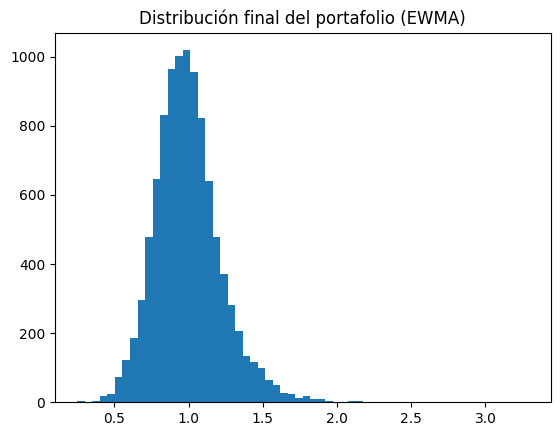

VaR 95%: 0.3306675405077022
Expected Shortfall 95%: 0.40862279595737716


In [6]:
final_values = portfolio_paths[:,-1]

plt.hist(final_values,bins=60)
plt.title("Distribución final del portafolio (EWMA)")
plt.show()

var_95 = np.percentile(final_values,5)
es_95 = final_values[final_values<=var_95].mean()

print("VaR 95%:",1-var_95)
print("Expected Shortfall 95%:",1-es_95)

# 8. Cierre

- El VaR depende de la distribución asumida.
- La distribución depende de la volatilidad.
- La volatilidad depende del régimen.
- EWMA introduce memoria y dinámica.
- **El riesgo no es un número fijo; depende del modelo y del entorno que asumimos.**

## ACTIVIDAD: 

Usando el portafolio elegido por ti en la actividad Rep 2. Checkpoint 3. Calcular VaR (%) para tu portafolio a 15 días al 95% de confianza con los siguientes procesos.

- Con MGB con volatilidad constante (como en el checkpoint 3.)
- Usando 1 año de data histórica
- Usando 3 años de data histórica
- Usando 5 años de data histórica
- Usando 10 años de data histórica
- Con EWMA (como visto en clase)
- Usando 1 año de data histórica. Lambda =.94
- Usando 3 años de data histórica. Lambda =.94
- Usando 5 años de data histórica. Lambda =.94
- Usando 10 años de data histórica. Lambda =.94
- Con EWMA (como visto en clase) 
- Usando 1 año de data histórica. Lambda =.8
- Usando 3 años de data histórica. Lambda =.8
- Usando 5 años de data histórica. Lambda =.8
- Usando 10 años de data histórica. Lambda =.8


Construye una tabla comparativa, dentro de tu codigo, con los resultados observados.

In [10]:
from scipy.stats import norm

# 1. Configuración del Portafolio
stocks = ['PLTR', 'GLD', 'TSLA', 'JNJ']
weights = np.array([0.3, 0.1, 0.4, 0.2])
confianza = 0.95
dias_horizonte = 15
años_analisis = [1, 3, 5, 10]

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

confianza = 0.95
dias_horizonte = 15
años_analisis = [1, 3, 5, 10]

end = dt.datetime.now()
start = end - dt.timedelta(days=365 * 10)

df = yf.download(stocks, start=start, end=end)['Close']
returns = df.pct_change().dropna()

[*********************100%***********************]  4 of 4 completed


In [11]:
tabla_comparativa = []

# Bucle de cálculo para cada periodo de tiempo
for años in años_analisis:
    # Filtrar datos por ventana de tiempo
    fecha_inicio = end - dt.timedelta(days=365 * años)
    retornos_ventana = returns[returns.index >= fecha_inicio]
    
    # --- MÉTODO 1: MGB Volatilidad Constante ---
    cov_matrix = retornos_ventana.cov()
    # Volatilidad del portafolio 
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    var_mgb = norm.ppf(confianza) * port_std * np.sqrt(dias_horizonte)
    
    tabla_comparativa.append({
        'Años Hist.': años, 
        'Método': 'MGB Constante', 
        'Lambda': '-', 
        'VaR 15d (%)': round(var_mgb * 100, 2)
    })
    
    # --- MÉTODO 2: EWMA (Lambdas 0.94 y 0.8) ---
    for lmbda in [0.94, 0.8]:
        # Retornos diarios del portafolio
        port_ret = (retornos_ventana * weights).sum(axis=1)
        
        # Cálculo de varianza recursiva EWMA
        varianzas = np.zeros(len(port_ret))
        varianzas[0] = port_ret.var() # Semilla inicial
        
        for t in range(1, len(port_ret)):
            varianzas[t] = lmbda * varianzas[t-1] + (1 - lmbda) * (port_ret.iloc[t-1]**2)
        
        # Usamos la última volatilidad calculada para el VaR
        sigma_ewma = np.sqrt(varianzas[-1])
        var_ewma = norm.ppf(confianza) * sigma_ewma * np.sqrt(dias_horizonte)
        
        tabla_comparativa.append({
            'Años Hist.': años, 
            'Método': 'EWMA', 
            'Lambda': lmbda, 
            'VaR 15d (%)': round(var_ewma * 100, 2)
        })

# 3. Construcción y visualización de la Tabla
df_final = pd.DataFrame(tabla_comparativa)

print("TABLA COMPARATIVA DE VaR (15 DÍAS, 95% CONFIANZA)")
print("=" * 60)
print(df_final.to_string(index=False))

TABLA COMPARATIVA DE VaR (15 DÍAS, 95% CONFIANZA)
 Años Hist.        Método Lambda  VaR 15d (%)
          1 MGB Constante      -        13.98
          1          EWMA   0.94        14.62
          1          EWMA    0.8        14.36
          3 MGB Constante      -        13.51
          3          EWMA   0.94        14.62
          3          EWMA    0.8        14.36
          5 MGB Constante      -        13.90
          5          EWMA   0.94        14.62
          5          EWMA    0.8        14.36
         10 MGB Constante      -        14.47
         10          EWMA   0.94        14.62
         10          EWMA    0.8        14.36


### Conclusión:

Podemos observar como los valores con EWMA son iguales con su respectivo $\lambda$, sin embargo el VaR que fue calculado con MGB si cambia.